Algoritmos para Lab - Testign

In [105]:
# Imports

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
def needleman_wunsch(seq1, seq2, MATCH_SCORE, MISMATCH_PENALTY, GAP_PENALTY):

    start = time.time()

    def similarity(a,b, MATCH_SCORE, MISMATCH_PENALTY):
        if a == b:
            return MATCH_SCORE
        else:
            return MISMATCH_PENALTY

    # Creating the empty matrix
    nwm = np.zeros((len(seq1) + 1,len(seq2) + 1))

    # Assigning starter values
    for i in range(nwm.shape[0]):
        for j in range(nwm.shape[1]):
            nwm[i,0] = GAP_PENALTY * i
            nwm[0,j] = GAP_PENALTY * j   

    #Filling out the rest of the matrix
    for i in range(1,nwm.shape[0]):
        for j in range(1, nwm.shape[1]):            
            top_value = nwm[i-1,j] + GAP_PENALTY
            left_value = nwm[i, j-1] + GAP_PENALTY

            if seq1[i-1] == seq2[j-1]:
                diagonal_value = nwm[i-1, j-1] + MATCH_SCORE
            else:
                diagonal_value = nwm[i-1, j-1] + MISMATCH_PENALTY

            nwm[i,j] = max(top_value, left_value, diagonal_value)
    
    #Traceback

    sequence1 = ''
    sequence2 = ''
    path_x = []
    path_y = []

    i, j = len(seq1), len(seq2)

    while (i > 0 or j > 0):
        path_x.append(i)
        path_y.append(j)

        if (i > 0 and j > 0 and nwm[i,j] == nwm[i-1,j-1] + similarity(seq1[i-1], seq2[j-1], MATCH_SCORE, MISMATCH_PENALTY)):
            sequence1 = seq1[i-1] + sequence1
            sequence2 = seq2[j-1] + sequence2
            i -= 1
            j -= 1
        elif (i > 0 and nwm[i,j] == nwm[i-1, j] + GAP_PENALTY):
            sequence1 = seq1[i-1] + sequence1
            sequence2 = '-' + sequence2
            i -= 1
        else:
            sequence1 = '-' + sequence1
            sequence2 = seq2[j-1] + sequence2
            j -= 1
    
    score = nwm[len(seq1), len(seq2)]
    time_taken = time.time() - start # The time taken to visualize the graph is not considered as time to complete the algorithm, so the timer stops here

    plt.figure(figsize=(8,8))

    sns.heatmap(nwm, xticklabels=[], yticklabels=[])

    plt.plot([x + 0.5 for x in reversed(path_x)],
             [y + 0.5 for y in reversed(path_y)],
             linewidth = 2, color='green')
    
    plt.title("Needleman-Wunsh")
    plt.show()

    return nwm, sequence2, sequence1, score, time_taken, path_x, path_y, seq2, seq1

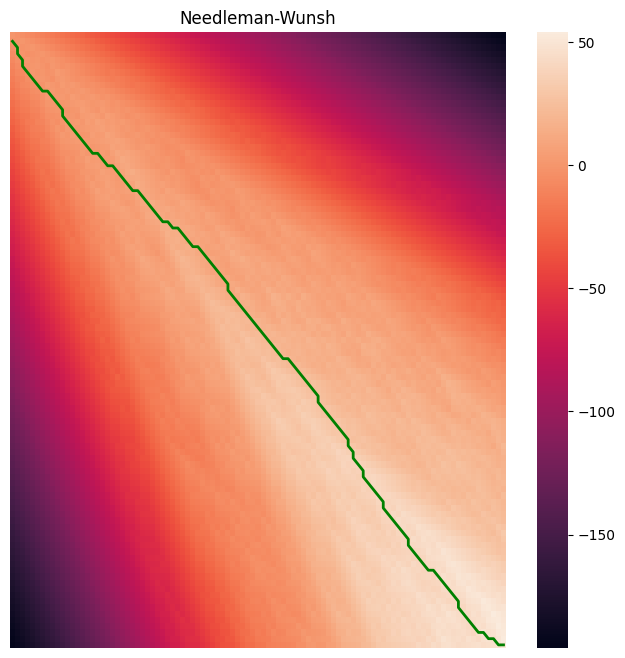

In [107]:
aligned_1 = needleman_wunsch("GACTTACGCGCCGTAGCACTTCTGTGATAGCTGCGAGGCGTATTGCTACTTGTACGAGATAGGGTCGACTTTTCGGAGTCGACAGACACTACGATACT",'AGTATCGTAGTGTCTGTCGACTCCGAAAAGTCGACCCTATCTCGTACAAGTAGCAATACGCCTCGCAGCTATCACAGAAGTGCTACGGCGCGTAAGTC', 2, -1, -2)

In [108]:
print(f'Sequence 1: {aligned_1[1]}')
print(f'Sequence 2: {aligned_1[2]}')

Sequence 1: AGTATCGTA-GTGTCTGTCG-AC-TCCG-AAAAG-T-CGA-CCCTATCTCGTACAAGTA-GCAATACGCCTCGCAGCTATCACAGAAGTGCTAC-GGCGCGTAAG-T-C-
Sequence 2: -G-A-CTTACGCG-CCGTAGCACTTCTGTGATAGCTGCGAGGCGTAT-TGCTACTTGTACGAGATA-GGGTCG-A-CT-TTTC-GGAGT-CGACAGACAC-TACGATACT
